# Dino Embeddings for Diversity Scoring

In [6]:
import torch
from torchvision import transforms
from PIL import Image

# load DINOv2
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
model.eval().cuda()
device = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5))
])

def embed(image_path):
    img = Image.open(image_path).convert("RGB")
    x = transform(img).unsqueeze(0).cuda()
    with torch.no_grad():
        feat = model(x)
    return feat.squeeze().cpu()

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


In [3]:
def load_image(path):
    return transform(Image.open(path))

In [2]:
from pathlib import Path

unlabeled_images = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n200_T15\Canari-Tyler-2026-04-24\labeled-data\Canari_n200"

image_paths = list(Path(unlabeled_images).rglob("*.jpg")) + \
              list(Path(unlabeled_images).rglob("*.png")) + \
              list(Path(unlabeled_images).rglob("*.jpeg"))

image_paths = [str(p) for p in image_paths]

print("Found images:", len(image_paths))

Found images: 400


In [4]:
def compute_embeddings(image_paths, batch_size=32):
    embeddings = []

    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i+batch_size]

        batch = torch.stack([load_image(p) for p in batch_paths]).to(device)

        with torch.no_grad():
            feats = model(batch)

        embeddings.append(feats.cpu())

    return torch.cat(embeddings, dim=0)

In [ ]:
import torch

def k_center_greedy(X, k):
    N = X.shape[0]

    selected = [torch.randint(0, N, (1,)).item()]

    dist = torch.cdist(X, X[selected]).min(dim=1).values

    for _ in range(k - 1):
        idx = torch.argmax(dist).item()
        selected.append(idx)

        new_dist = torch.cdist(X, X[[idx]]).squeeze(1)
        dist = torch.minimum(dist, new_dist)

    return selected

In [ ]:
X = compute_embeddings(image_paths)
X = X / X.norm(dim=1, keepdim=True)

In [17]:
k = 20  # batch size you want to label next

chosen_idx = k_center_greedy(X, k)

selected_images = [image_paths[i] for i in chosen_idx]

print(selected_images[:10])

['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\ModelBuildExperiments\\DavidBowie_n200_T15\\Canari-Tyler-2026-04-24\\labeled-data\\Canari_n200\\DavidBowie_20250828_F15_cam2_0083.png', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\ModelBuildExperiments\\DavidBowie_n200_T15\\Canari-Tyler-2026-04-24\\labeled-data\\Canari_n200\\DavidBowie_20250828_F15_cam1_0541.png', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\ModelBuildExperiments\\DavidBowie_n200_T15\\Canari-Tyler-2026-04-24\\labeled-data\\Canari_n200\\DavidBowie_20250828_F15_cam2_1418.png', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\ModelBuildExperiments\\DavidBowie_n200_T15\\Canari-Tyler-2026-04-24\\labeled-data\\Canari_n200\\DavidBowie_20250828_F15_cam1_1561.png', 'C:\\Users\\Salle-Cineradio\\Do

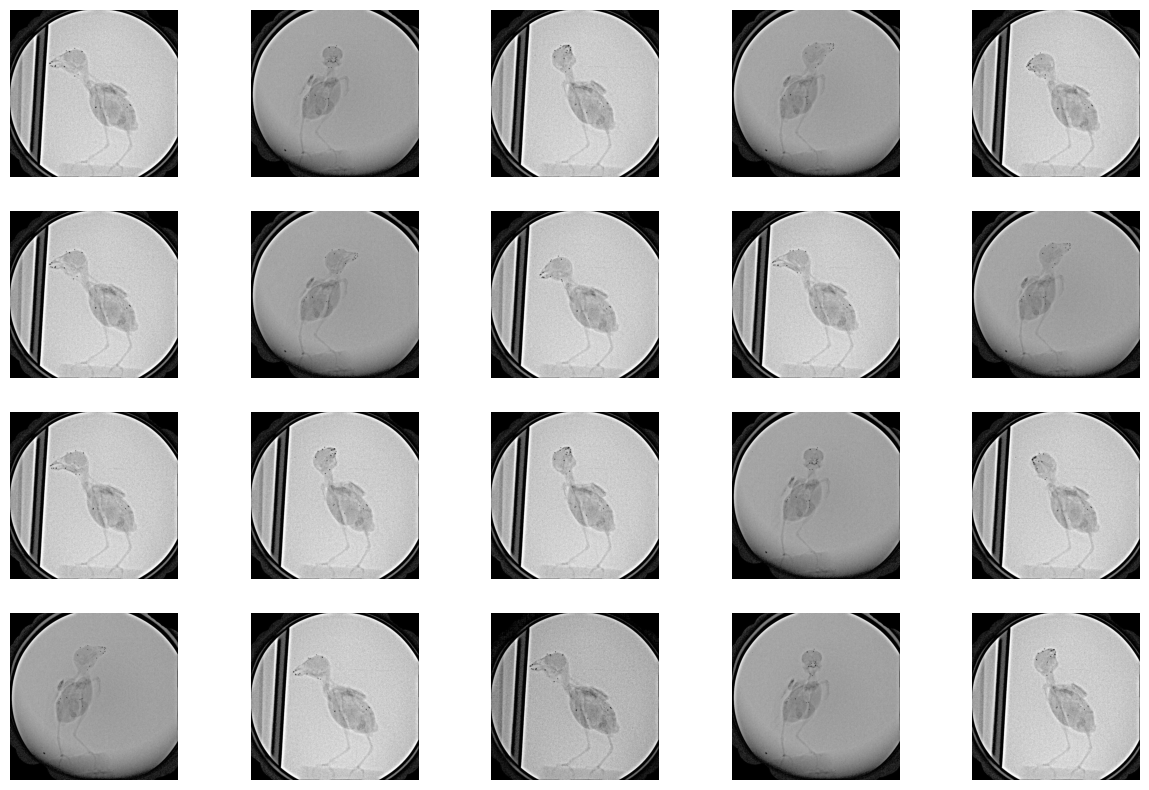

In [18]:
# plot images
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))
for i, img_path in enumerate(selected_images[:20]):
    img = Image.open(img_path)
    plt.subplot(4, 5, i+1)
    plt.imshow(img)
    plt.axis('off')

Computing embeddings for 50 images...
Computing embeddings for 100 images...
Computing embeddings for 150 images...
Computing embeddings for 200 images...
Computing embeddings for 250 images...
Computing embeddings for 300 images...
Computing embeddings for 350 images...
Computing embeddings for 400 images...
Time taken for different image counts:


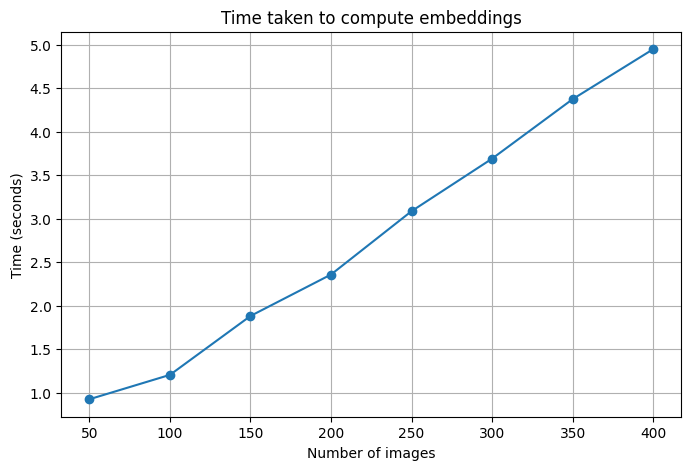

In [19]:
# time test
import time
time_vals = {}
for len_images in [50, 100, 150, 200, 250, 300, 350, 400]:
    print(f"Computing embeddings for {len_images} images...")
    start_time = time.time()
    X = compute_embeddings(image_paths[:len_images])
    X = X / X.norm(dim=1, keepdim=True)
    time_vals[len_images] = time.time() - start_time

print("Time taken for different image counts:")
plot_x = list(time_vals.keys())
plot_y = list(time_vals.values())
plt.figure(figsize=(8, 5))
plt.plot(plot_x, plot_y, marker='o')
plt.title("Time taken to compute embeddings")
plt.xlabel("Number of images")
plt.ylabel("Time (seconds)")
plt.grid()
plt.show()
